In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
enron = pd.read_csv('../data/enron_model_ft.csv')

/var/folders/4y/0t9f134178bbfj5m299wl_7h0000gn/T/ipykernel_30158/1053813020.py:1: DtypeWarning: Columns (2,4,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  enron = pd.read_csv('../data/enron_model_ft.csv')


In [5]:
def bucket_urgency(minutes):
    if pd.isna(minutes):
        return 'ghosted'
    elif minutes < 5:
        return 'instant'
    elif minutes < 15:
        return 'fast'
    elif minutes < 24*60:
        return 'same_day'
    else:
        return 'next_day'

enron['urgency_bucket'] = enron['response_time'].apply(bucket_urgency)
enron['urgency_bucket'].value_counts()

urgency_bucket
ghosted     344643
same_day      8677
instant       2977
fast          2346
next_day      1108
Name: count, dtype: int64

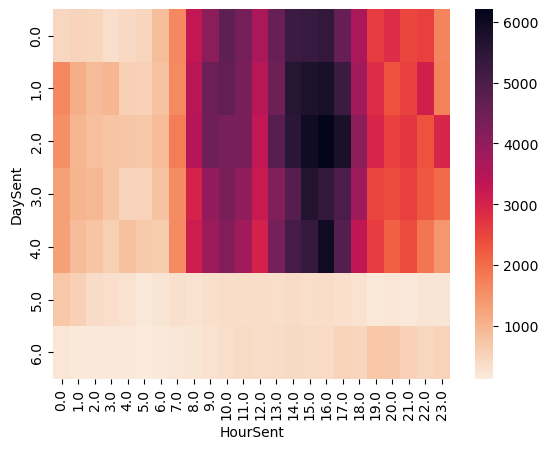

In [6]:
pivot = enron.pivot_table(index='DaySent', columns='HourSent', values='EmailSend', aggfunc='count')
sns.heatmap(pivot, cmap='rocket_r');

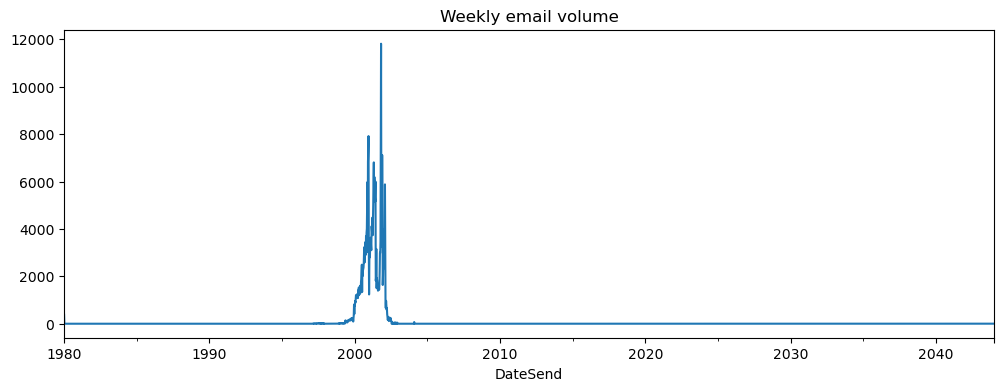

In [7]:
enron['DateSend'] = pd.to_datetime(enron['DateSend'])
enron.set_index('DateSend').resample('W').size().plot(figsize=(12,4), title='Weekly email volume');

(1462.0, 1775.0)

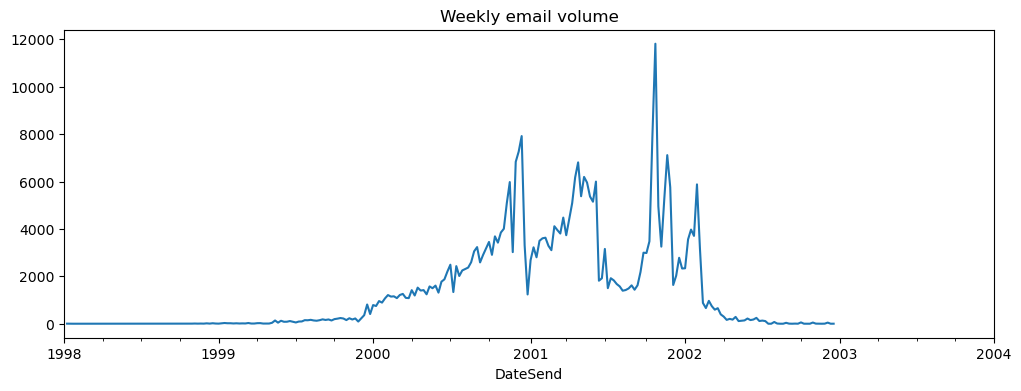

In [9]:
enron['DateSend'] = pd.to_datetime(enron['DateSend'], errors='coerce')

ax = enron_clean.set_index('DateSend').resample('W').size().plot(
    figsize=(12,4), title='Weekly email volume'
)
ax.set_xlim(pd.Timestamp('1998-01-01'), pd.Timestamp('2003-12-31'))